In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import editdistance
from sklearn.metrics import accuracy_score

In [3]:
# Constants
IMAGE_SIZE = (128, 32)
BATCH_SIZE = 64
EPOCHS = 50
PADDING_TOKEN = 99
DATA_INPUT_PATH = '/content/drive/MyDrive/IAM_handwriting_dataset/iam_words'
MODEL_NAME = 'HWR_MODEL'
MODEL_OUTPUT_PATH = '/content/drive/MyDrive/HWR_model'

In [4]:
# Global variables
images_path = []
labels = []

def preprocess_dataset():
    characters = set()
    max_len = 0
    with open(os.path.join(DATA_INPUT_PATH, 'words.txt'), 'r') as file:
        lines = file.readlines()
        for line in lines:
            if line.startswith('#') or line.strip() == '':
                continue
            parts = line.strip().split()
            word_id = parts[0]
            first_folder = word_id.split("-")[0]
            second_folder = f"{first_folder}-{word_id.split('-')[1]}"
            image_filename = f"{word_id}.png"
            image_path = os.path.join(DATA_INPUT_PATH, 'words', first_folder, second_folder, image_filename)
            if os.path.isfile(image_path) and os.path.getsize(image_path):
                images_path.append(image_path)
                label = parts[-1].strip()
                for char in label:
                    characters.add(char)
                max_len = max(max_len, len(label))
                labels.append(label)

    characters = sorted(list(characters))
    print('characters:', characters)
    print('max_len:', max_len)
    char_to_num = tf.keras.layers.StringLookup(vocabulary=list(characters), mask_token=None)
    num_to_char = tf.keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True)
    return characters, char_to_num, num_to_char, max_len

characters, char_to_num, num_to_char, max_len = preprocess_dataset()

characters: ['!', '"', '#', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
max_len: 19


In [5]:
def distortion_free_resize(image, img_size):
    w, h = img_size
    image = tf.image.resize(image, size=(h, w), preserve_aspect_ratio=True)
    pad_height = h - tf.shape(image)[0]
    pad_width = w - tf.shape(image)[1]
    if pad_height % 2 != 0:
        height = pad_height // 2
        pad_height_top = height + 1
        pad_height_bottom = height
    else:
        pad_height_top = pad_height_bottom = pad_height // 2
    if pad_width % 2 != 0:
        width = pad_width // 2
        pad_width_left = width + 1
        pad_width_right = width
    else:
        pad_width_left = pad_width_right = pad_width // 2
    image = tf.pad(image, paddings=[[pad_height_top, pad_height_bottom], [pad_width_left, pad_width_right], [0, 0]])
    image = tf.transpose(image, perm=[1, 0, 2])
    image = tf.image.flip_left_right(image)
    return image

In [6]:
def preprocess_image(image_path, img_size):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, 1)
    image = distortion_free_resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def vectorize_label(label):
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
    length = tf.shape(label)[0]
    pad_amount = max_len - length
    label = tf.pad(label, paddings=[[0, pad_amount]], constant_values=PADDING_TOKEN)
    return label

def process_images_labels(image_path, label):
    image = preprocess_image(image_path, IMAGE_SIZE)
    label = vectorize_label(label)
    return {"image": image, "label": label}

def prepare_dataset(image_paths, labels):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels)).map(
        process_images_labels, num_parallel_calls=tf.data.AUTOTUNE
    )
    return dataset.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

def split_dataset():
    train_images, test_images, train_labels, test_labels = train_test_split(
        images_path, labels, test_size=0.2, random_state=42
    )
    val_images, test_images, val_labels, test_labels = train_test_split(
        test_images, test_labels, test_size=0.5, random_state=42
    )
    train_set = prepare_dataset(train_images, train_labels)
    val_set = prepare_dataset(val_images, val_labels)
    test_set = prepare_dataset(test_images, test_labels)
    return train_set, val_set, test_set

train_set, val_set, test_set = split_dataset()


In [7]:
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
        label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")
        input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

In [8]:
def build_model():
    input_img = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1), name="image")
    labels = tf.keras.layers.Input(name="label", shape=(None,))
    x = tf.keras.layers.Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(input_img)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    new_shape = ((IMAGE_SIZE[0] // 4), (IMAGE_SIZE[1] // 4) * 64)
    x = tf.keras.layers.Reshape(target_shape=new_shape)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.25))(x)
    x = tf.keras.layers.Dense(len(char_to_num.get_vocabulary()) + 2, activation="softmax", name="dense2")(x)
    output = CTCLayer(name="ctc_loss")(labels, x)
    model = tf.keras.models.Model(inputs=[input_img, labels], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
    model.summary()
    return model

model = build_model()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 32,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 32,   │        320 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 16,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 8, 64) │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 512)   │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32, 64)    │     32,832 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32, 256)   │    197,632 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 32, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 32, 79)    │     10,191 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_loss (CTCLayer) │ (None, 32, 79)    │          0 │ label[0][0],      │
│                     │                   │            │ dense2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 423,823 (1.62 MB)

 Trainable params: 423,823 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][:, :max_len]
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    return output_text

class EditDistanceCallback(tf.keras.callbacks.Callback):
    def __init__(self, pred_model, max_len, validation_images, validation_labels):
        super().__init__()
        self.prediction_model = pred_model
        self.max_len = max_len
        self.validation_images = validation_images
        self.validation_labels = validation_labels
        self.val_accuracies = []
        self.val_wers = []
        self.val_cers = []

    def calculate_metrics(self, images, labels):
        predictions = self.prediction_model.predict(images, verbose=0)
        pred_texts = decode_batch_predictions(predictions)
        true_texts = []
        for label in labels:
            label = tf.gather(label, tf.where(tf.math.not_equal(label, PADDING_TOKEN)))
            true_text = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
            true_texts.append(true_text)

        # Accuracy: Consider a prediction correct if it matches the true text exactly
        correct = sum(1 for pred, true in zip(pred_texts, true_texts) if pred == true)
        accuracy = correct / len(true_texts)

        # WER and CER
        wer = np.mean([editdistance.eval(pred.split(), true.split()) / max(len(true.split()), 1)
                       for pred, true in zip(pred_texts, true_texts)])
        cer = np.mean([editdistance.eval(pred, true) / max(len(true), 1)
                       for pred, true in zip(pred_texts, true_texts)])

        return accuracy, wer, cer

    def on_epoch_end(self, epoch, logs=None):
        val_accuracies, val_wers, val_cers = [], [], []
        for i in range(len(self.validation_images)):
            acc, wer, cer = self.calculate_metrics(self.validation_images[i], self.validation_labels[i])
            val_accuracies.append(acc)
            val_wers.append(wer)
            val_cers.append(cer)
        mean_acc = np.mean(val_accuracies)
        mean_wer = np.mean(val_wers)
        mean_cer = np.mean(val_cers)
        self.val_accuracies.append(mean_acc)
        self.val_wers.append(mean_wer)
        self.val_cers.append(mean_cer)
        print(f"Epoch {epoch + 1}: Val Accuracy: {mean_acc:.4f}, Val WER: {mean_wer:.4f}, Val CER: {mean_cer:.4f}")


In [10]:
def train_model():
    validation_images = []
    validation_labels = []
    for batch in val_set:
        validation_images.append(batch["image"])
        validation_labels.append(batch["label"])

    prediction_model = tf.keras.models.Model(model.input[0], model.get_layer(name="dense2").output)
    edit_distance_callback = EditDistanceCallback(prediction_model, max_len, validation_images, validation_labels)
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=EPOCHS,
        callbacks=[edit_distance_callback, early_stopping],
    )
    return history, prediction_model, edit_distance_callback

history, prediction_model, edit_distance_callback = train_model()

def evaluate_model():
    test_images = []
    test_labels = []
    for batch in test_set:
        test_images.append(batch["image"])
        test_labels.append(batch["label"])

    accuracies, wers, cers = [], [], []
    for i in range(len(test_images)):
        acc, wer, cer = edit_distance_callback.calculate_metrics(test_images[i], test_labels[i])
        accuracies.append(acc)
        wers.append(wer)
        cers.append(cer)

    print(f"Test Accuracy: {np.mean(accuracies):.4f}")
    print(f"Test WER: {np.mean(wers):.4f}")
    print(f"Test CER: {np.mean(cers):.4f}")

evaluate_model()

Epoch 1/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - loss: 1307.2984 Epoch 1: Val Accuracy: 0.0000, Val WER: 1.0000, Val CER: 1.0000
558/558 ━━━━━━━━━━━━━━━━━━━━ 11618s 21s/step - loss: 1002.7460 - val_loss: 876.6848
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - loss: 864.0369Epoch 2: Val Accuracy: 0.0901, Val WER: 0.9099, Val CER: 0.8005
558/558 ━━━━━━━━━━━━━━━━━━━━ 417s 748ms/step - loss: 847.0450 - val_loss: 813.1141
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - loss: 801.8585Epoch 3: Val Accuracy: 0.1777, Val WER: 0.8223, Val CER: 0.6815
558/558 ━━━━━━━━━━━━━━━━━━━━ 445s 754ms/step - loss: 788.4109 - val_loss: 744.8191
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - loss: 744.5507Epoch 4: Val Accuracy: 0.2162, Val WER: 0.7838, Val CER: 0.6397
558/558 ━━━━━━━━━━━━━━━━━━━━ 419s 750ms/step - loss: 730.6534 - val_loss: 682.8504
Epoch 5/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - loss: 689.7257Epoch 5: Val Accuracy: 0.2344, Val WER: 0.7656, Val CER: 0.59

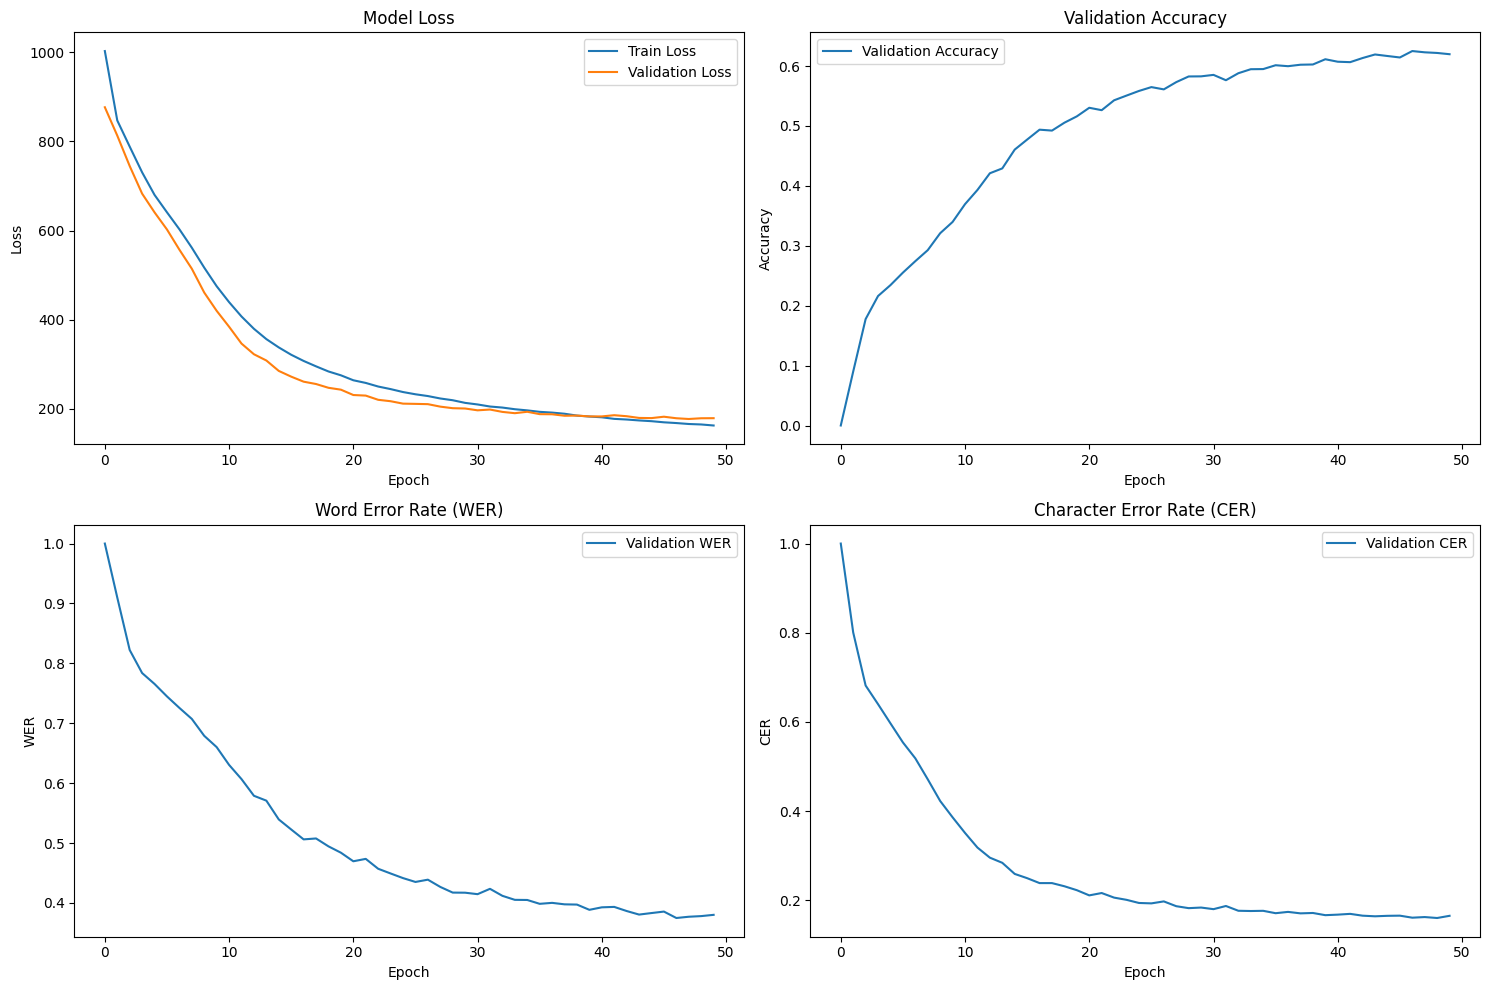

In [11]:
def save_model():
    os.makedirs(MODEL_OUTPUT_PATH, exist_ok=True)
    prediction_model.save(os.path.join(MODEL_OUTPUT_PATH, f'{MODEL_NAME}.keras'))

save_model()

def visualize_metrics(history, edit_distance_callback):
    plt.figure(figsize=(15, 10))

    # Plot training & validation loss
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
# Plot validation accuracy
    plt.subplot(2, 2, 2)
    plt.plot(edit_distance_callback.val_accuracies, label='Validation Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
# Plot WER
    plt.subplot(2, 2, 3)
    plt.plot(edit_distance_callback.val_wers, label='Validation WER')
    plt.title('Word Error Rate (WER)')
    plt.xlabel('Epoch')
    plt.ylabel('WER')
    plt.legend()
# Plot CER
    plt.subplot(2, 2, 4)
    plt.plot(edit_distance_callback.val_cers, label='Validation CER')
    plt.title('Character Error Rate (CER)')
    plt.xlabel('Epoch')
    plt.ylabel('CER')
    plt.legend()

    plt.tight_layout()
    plt.show()

visualize_metrics(history, edit_distance_callback)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


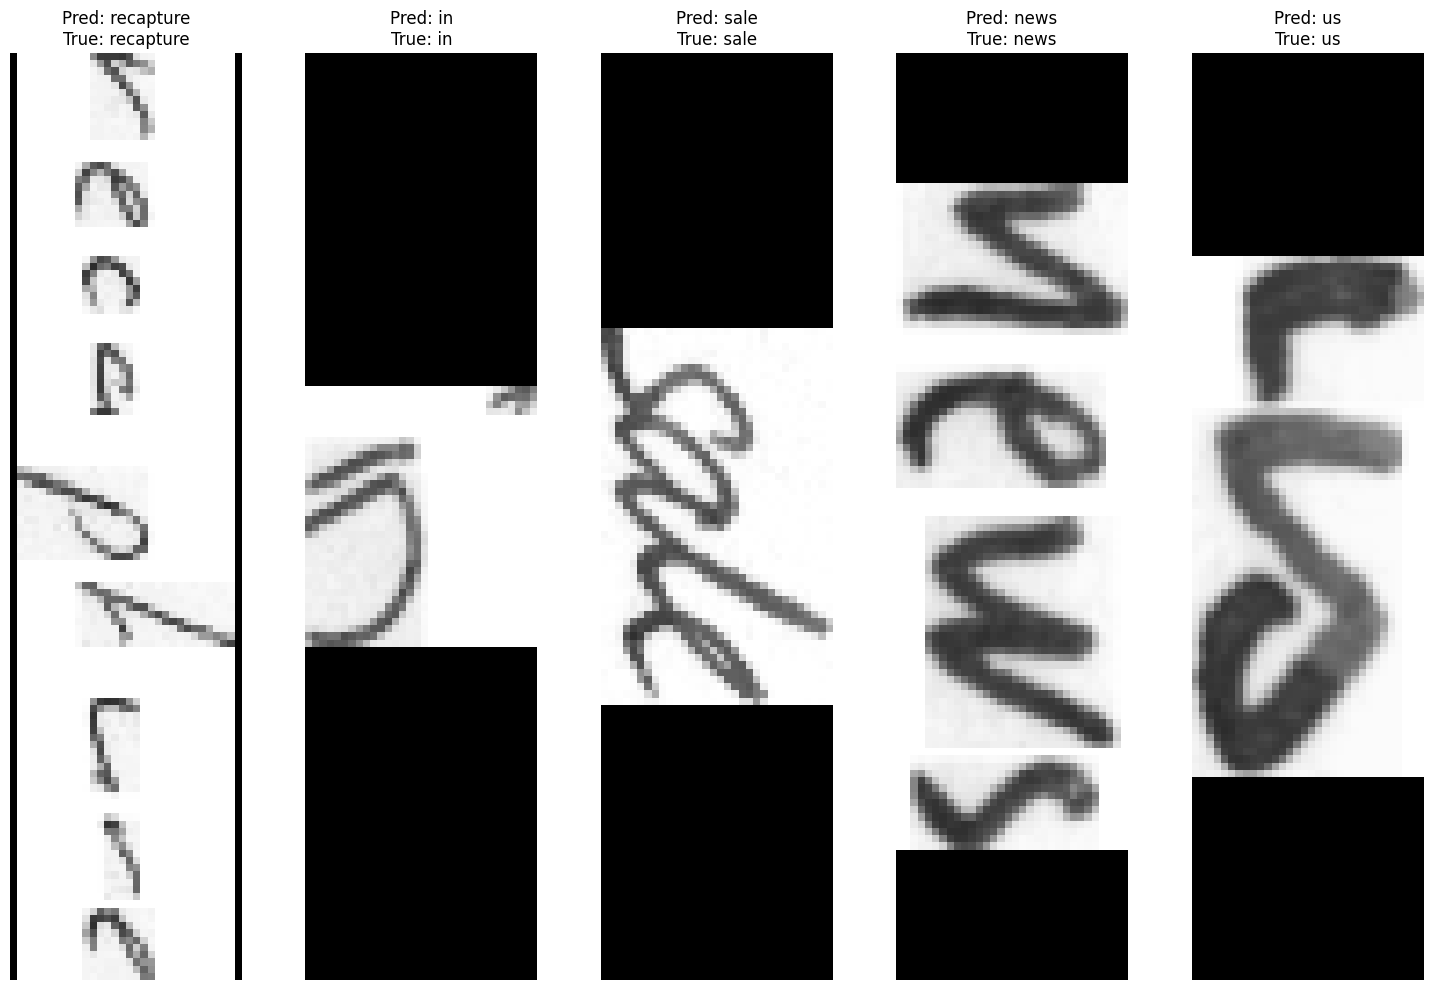

In [12]:
def visualize_predictions():
    # Get a batch from the test set
    test_images = []
    test_labels = []
    for batch in test_set.take(1):  # Take one batch
        test_images = batch["image"].numpy()
        test_labels = batch["label"].numpy()

    # Get predictions
    predictions = prediction_model.predict(test_images)
    pred_texts = decode_batch_predictions(predictions)

    # Convert labels to text
    true_texts = []
    for label in test_labels:
        label = tf.gather(label, tf.where(tf.math.not_equal(label, PADDING_TOKEN)))
        true_text = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
        true_texts.append(true_text)

    # Plot images with predicted and true texts
    plt.figure(figsize=(15, 10))
    for i in range(min(5, len(test_images))):  # Display up to 5 samples
        plt.subplot(1, 5, i + 1)
        plt.imshow(test_images[i].squeeze(), cmap='gray')
        plt.title(f"Pred: {pred_texts[i]}\nTrue: {true_texts[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function after evaluate_model()
visualize_predictions()

In [22]:
def predict_custom_image(image_path):
    """
    Predict text from a custom uploaded image and display it.

    Args:
        image_path (str): Path to the custom image file (e.g., 'path/to/image.png').
    """
    try:
        # Preprocess the custom image
        processed_image = preprocess_image(image_path, IMAGE_SIZE)
        # Add batch dimension for model prediction
        model_input_image = tf.expand_dims(processed_image, axis=0) # Shape: [1, 128, 32, 1]

        # Predict using the prediction model
        prediction = prediction_model.predict(model_input_image, verbose=0)
        pred_text = decode_batch_predictions(prediction)[0] # Get first (and only) prediction

        # Load raw image for display (without preprocessing, for visual clarity)
        raw_image_data = tf.io.read_file(image_path)
        raw_image_data = tf.image.decode_png(raw_image_data, channels=1)
        raw_image_data = raw_image_data.numpy().squeeze() # Remove channel dimension if present

        # Display the images and predicted text
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Subplot 1: Raw Image
        axes[0].imshow(raw_image_data, cmap='gray')
        axes[0].set_title("Original Image")
        axes[0].axis('off')

        # Subplot 2: Processed Image (what the model sees)
        axes[1].imshow(processed_image.numpy().squeeze(), cmap='gray')
        axes[1].set_title("Processed Input to Model")
        axes[1].axis('off')

        fig.suptitle(f"Predicted Text: {pred_text}", fontsize=14, y=0.95)
        plt.tight_layout(rect=[0, 0, 1, 0.9]) # Adjust layout to make space for suptitle
        plt.show()

    except Exception as e:
        print(f"Error processing image: {str(e)}")

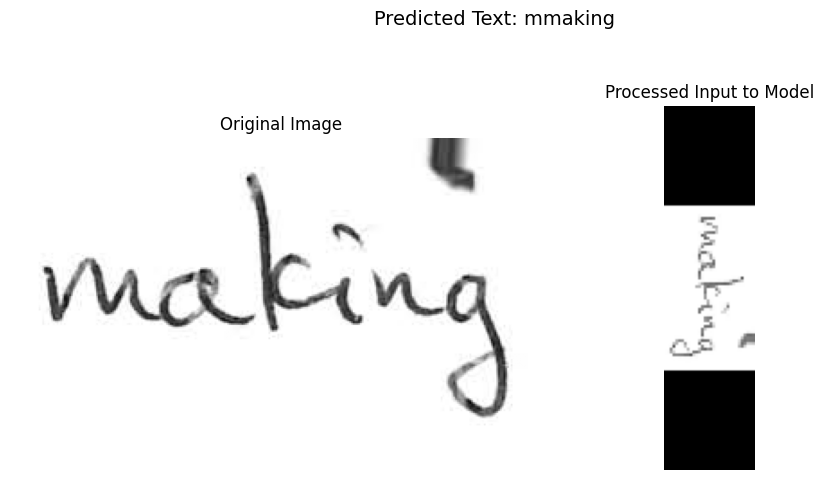

In [23]:
 predict_custom_image('/content/drive/MyDrive/custom image.jpg')